# Preparation

To prepare, we imported all the necessary libraries as well as the dataset.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer, load_digits, load_iris
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Importing the data set

We used a large dataset on used car salesprices sourced from Kaggle. It contains over 400,000 entries.

__PLEASE NOTE__

Sometimes loading in the data causes an error. Try reuploading the dataset or running the cell until it works. It tends to work eventually. Otherwise, you may need to restart the codespace.

In [2]:
data = pd.read_csv('/content/vehicles.csv', engine='python')

In [3]:
# Sample 10% of data — still 42,000 rows, plenty for modeling
data = data.sample(frac=0.1, random_state=42)
data.reset_index(drop=True, inplace=True)

In [4]:
# Preview data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42712 entries, 0 to 42711
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            42712 non-null  int64  
 1   url           42712 non-null  object 
 2   region        42712 non-null  object 
 3   region_url    42712 non-null  object 
 4   price         42712 non-null  int64  
 5   year          42595 non-null  float64
 6   manufacturer  40927 non-null  object 
 7   model         42228 non-null  object 
 8   condition     25296 non-null  object 
 9   cylinders     24980 non-null  object 
 10  fuel          42408 non-null  object 
 11  odometer      42294 non-null  float64
 12  title_status  41896 non-null  object 
 13  transmission  42482 non-null  object 
 14  VIN           26522 non-null  object 
 15  drive         29647 non-null  object 
 16  size          12033 non-null  object 
 17  type          33455 non-null  object 
 18  paint_color   29676 non-nu

# Data Cleaning

The first step in cleaning the data was clearing the useless columns. Customer ID, VIN, description, and various URLs would not be useful in determining sale price, so we dropped these from the data set.

We previously ran this data without adressing large outliers in price, which meant hugely negative r-squared values. We elaborate on this in the report, but for now, we also need to work with price to slim it down to reasonable values.

In [5]:
# Drop useless columns
data.drop(['county', 'id', 'url', 'region_url', 'VIN', 'image_url', 'description'], axis=1, inplace=True)

In [6]:
# Figure out what is happening with price by describing the data
print(data['price'].describe())
print("\nSuspicious values:")

# Print different sectors of data that would represent likely outliers
print(f"Prices = $0: {(data['price'] == 0).sum()}")
print(f"Prices < $100: {(data['price'] < 100).sum()}")
print(f"Prices > $100,000: {(data['price'] > 100000).sum()}")

count    4.271200e+04
mean     4.347691e+04
std      5.376233e+06
min      0.000000e+00
25%      5.893250e+03
50%      1.376150e+04
75%      2.600000e+04
max      1.111111e+09
Name: price, dtype: float64

Suspicious values:
Prices = $0: 3319
Prices < $100: 3636
Prices > $100,000: 56


In [7]:
# Recreate the dataframe without these likely outliers
# finding only the cars within reasonable price ranges.

data = data[(data['price'] >= 500) & (data['price'] <= 75000)]

# We still have over 38,000 datapoints remaining in this case, which is plenty to work with.
print(f"Rows remaining: {len(data)}")

Rows remaining: 38255


count    38255.000000
mean     18826.365312
std      13853.065097
min        500.000000
25%       7500.000000
50%      15500.000000
75%      27776.000000
max      75000.000000
Name: price, dtype: float64


Text(0.5, 0, 'Price ($)')

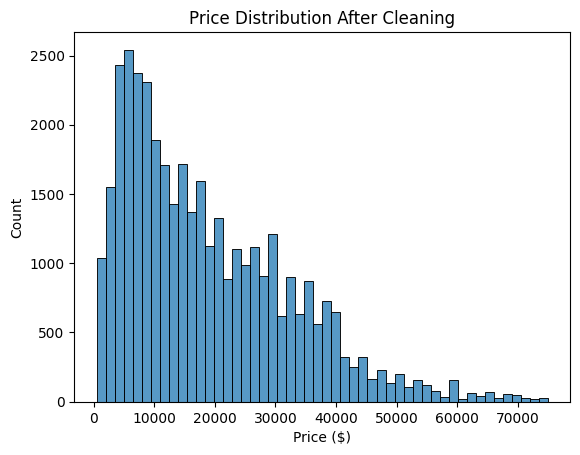

In [8]:
# Re-examine price distribtion
# Prices appear much more reasonable now.
print(data['price'].describe())
sns.histplot(data['price'], bins=50)
plt.title('Price Distribution After Cleaning')
plt.xlabel('Price ($)')

# Feature Engineering

Next, we added a few columns that may be more useful factors in determining the sale price of a vehicle.

Here are some features we made from the dataset:

1.  __Vehicle Age__: The age of the car (current year - manufacturing year).
2.  __Miles Per Year__: The average miles driven per year (odometer / vehicle age).
3.  __Is Luxury Brand__: A binary indicator if the car manufacturer is considered a luxury brand.

### 1. Vehicle Age

We calculated the age of the vehicle using its `year` of manufacture and the `posting_date` of the listing.

In [9]:
# Impute missing 'year' values with the median year
median_year = data['year'].median()
data['year'] = data['year'].fillna(median_year)

# Convert 'posting_date' to datetime objects and extract the year
data['posting_date'] = pd.to_datetime(data['posting_date'], errors='coerce', utc=True)
data['posting_year'] = data['posting_date'].dt.year

# Impute missing 'posting_year' with the mode
mode_posting_year = data['posting_year'].mode()[0]
data['posting_year'] = data['posting_year'].fillna(mode_posting_year)

# Calculate vehicle age
data['vehicle_age'] = data['posting_year'] - data['year']

### 2. Miles Per Year

This feature tells us roughly how much a car was driven annually, which might tell us more about wear and tear. We calculated it by dividing `odometer` by `vehicle_age`.

In [10]:
# Impute missing 'odometer' values with the median
median_odometer = data['odometer'].median()
data['odometer'] = data['odometer'].fillna(median_odometer)

# Calculate miles_per_year, handling division by zero for new cars (age=0)
data['miles_per_year'] = data.apply(lambda row: row['odometer'] / row['vehicle_age'] if row['vehicle_age'] > 0 else 0, axis=1)

### 3. Is Luxury Brand

We also created a binary variable to indicate whether a car belongs to a luxury manufacturer, which would probably be linked to higher prices.

In [11]:
# Defines a rough list of known luxury car manufacturers
luxury_brands = ['mercedes-benz', 'bmw', 'audi', 'lexus', 'acura', 'infiniti', 'cadillac', 'tesla', 'porsche', 'land rover', 'jaguar', 'maserati', 'rolls-royce', 'bentley', 'aston martin', 'ferrari', 'lamborghini']

# Convert 'manufacturer' to lowercase for consistent matching and fill NaNs
data['manufacturer_lower'] = data['manufacturer'].str.lower()
data['manufacturer_lower'] = data['manufacturer_lower'].fillna('unknown')

# Create the 'is_luxury' feature
data['is_luxury'] = data['manufacturer_lower'].apply(lambda x: 1 if x in luxury_brands else 0)

In [12]:
# check to see if new collumns loaded in correctly
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38255 entries, 0 to 42711
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   region              38255 non-null  object             
 1   price               38255 non-null  int64              
 2   year                38255 non-null  float64            
 3   manufacturer        36711 non-null  object             
 4   model               37853 non-null  object             
 5   condition           23899 non-null  object             
 6   cylinders           22723 non-null  object             
 7   fuel                37987 non-null  object             
 8   odometer            38255 non-null  float64            
 9   title_status        37555 non-null  object             
 10  transmission        38092 non-null  object             
 11  drive               26594 non-null  object             
 12  size                10770 non-null  o

# Train/Test Split

In order to test the predictive value of our data, we need to first split it into train and test data.

In [13]:
# Drop rows where 'price' is NaN
data.dropna(subset=['price'], inplace=True)

# Set X equal to all collumns except price
X = data.drop('price', axis=1)
# Drop the original 'posting_date' column as 'posting_year' and 'vehicle_age' have been derived
X.drop('posting_date', axis=1, inplace=True)

# Set Y equal to price, the target variable
y = data['price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Imputation and fitting to models

Many of the entries in the data are missing values. To fix this, we imputted them with the appropriate values.

Additionally, categorical variables will be one-hot encoded, and numeric values will be scaled.

We then fit the data to four different models to explore which one is the strongest predictor: KNN, LGR, Decision Tree, and Random Forest

In [14]:
# initialize onehotencoder for categorical vars
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# initialize an imputer to fill the missing numeric values with median
imp_num = SimpleImputer(strategy = 'median')

# intialize an imputer to fill missing categorical values with the most frequently occuring in their collumn
imp_cat = SimpleImputer(strategy = 'most_frequent')

# initialize a scale to scale remaining numeric data
scale = StandardScaler()

In [15]:
# Select numerical columns from X_train
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# Select categorical columns from X_train
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

print("Numerical columns identified:", num_cols)
print("Categorical columns identified:", cat_cols)

Numerical columns identified: ['year', 'odometer', 'lat', 'long', 'posting_year', 'vehicle_age', 'miles_per_year', 'is_luxury']
Categorical columns identified: ['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'state', 'manufacturer_lower']


In [16]:
# Check categorical collumns to see if any are too diverse for OHE
for col in cat_cols:
    print(f"{col}: {X_train[col].nunique()} unique values")

region: 403 unique values
manufacturer: 39 unique values
model: 6934 unique values
condition: 6 unique values
cylinders: 8 unique values
fuel: 5 unique values
title_status: 6 unique values
transmission: 3 unique values
drive: 3 unique values
size: 4 unique values
type: 13 unique values
paint_color: 12 unique values
state: 51 unique values
manufacturer_lower: 40 unique values


In [17]:
# since 'model' has over 7000 unique values, it gets dropped
data.drop('model', axis=1, inplace=True)
X_train.drop('model', axis=1, inplace=True)
X_test.drop('model', axis=1, inplace=True)

# since region has over 400 unique values, it also gets dropped
data.drop('region', axis=1, inplace=True)
X_train.drop('region', axis=1, inplace=True)
X_test.drop('region', axis=1, inplace=True)

# Re-select numerical and categorical columns after dropping 'model' and 'region'
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

In [18]:
# initialize the collective imputer to do the actions described above to the chosen numeric and categorical collumns
# anything leftover will be left alone
imputer = make_column_transformer((imp_num, num_cols),
                             (imp_cat, cat_cols),
                                verbose_feature_names_out=False,
                             remainder = 'passthrough').set_output(transform="pandas")

# Create a combined feature transformer for encoding categorical and scaling numerical features
# This explicitly applies OneHotEncoder to cat_cols and StandardScaler to num_cols
feature_transformer = make_column_transformer(
    (ohe, cat_cols),  # Apply OneHotEncoder to categorical columns
    (scale, num_cols), # Apply StandardScaler to numerical columns
    remainder='passthrough' # Pass through any other columns (should be since num_cols + cat_cols cover all)
).set_output(transform="pandas")

In [19]:
# initialize the pipelines for each model, using the new feature_transformer
lgr_pipe = make_pipeline(imputer, feature_transformer, LinearRegression())
knn_pipe = make_pipeline(imputer, feature_transformer, KNeighborsRegressor())
rf_pipe = make_pipeline(imputer, feature_transformer, RandomForestRegressor())
dt_pipe = make_pipeline(imputer, feature_transformer, DecisionTreeRegressor())

# Fitting the Data

Now that the models have been initialized and the imputers have been set up, we can now fit the data to each model.

__PLEASE NOTE__

You may need to connect to a high-RAM runtime in order to fit the models, and fitting may take a few minutes because the dataset is quite large.


In [20]:
lgr_pipe.fit(X_train, y_train)
knn_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)
dt_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('simpleimputer-1',
                                                  SimpleImputer(strategy='median'),
                                                  ['year', 'odometer', 'lat',
                                                   'long', 'posting_year',
                                                   'vehicle_age',
                                                   'miles_per_year',
                                                   'is_luxury']),
                                                 ('simpleimputer-2',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['manufacturer', 'condition',
                                                   'cylinders', 'fuel',
                                                   'titl...
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['manufacturer', 'condition',
                                                   'cylinders', 'fuel',
                                                   'title_status',
                                                   'transmission', 'drive',
                                                   'size', 'type',
                                                   'paint_color', 'state',
                                                   'manufacturer_lower']),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  ['year', 'odometer', 'lat',
                                                   'long', 'posting_year',
                                                   'vehicle_age',
                                                   'miles_per_year',
                                                   'is_luxury'])])),
                ('decisiontreeregressor', DecisionTreeRegressor())])

# Testing Each Model

Now that the data has been fitted to each model, we want to test each one to decide which to move forward with.

In [21]:
models = {
    'Linear Regression': lgr_pipe,
    'KNN': knn_pipe,
    'Decision Tree': dt_pipe,
    'Random Forest': rf_pipe}

for name, model in models.items():
    preds = model.predict(X_test)
    print(f"\n{name}")
    print(f"  R²:   {r2_score(y_test, preds):.4f}")
    print(f"  MAE:  {mean_absolute_error(y_test, preds):,.0f}")
    print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, preds)):,.0f}")


Linear Regression
  R²:   0.4650
  MAE:  7,408
  RMSE: 10,324

KNN
  R²:   0.6690
  MAE:  5,410
  RMSE: 8,121

Decision Tree
  R²:   0.6319
  MAE:  4,760
  RMSE: 8,564

Random Forest
  R²:   0.8049
  MAE:  3,741
  RMSE: 6,235


# Refining

The Random Forest model already appears to be the most desireable, explaining over 80% of the variance in the data. However, we may still be able to refine the model a bit more through a grid search.

__PLEASE NOTE__

This code may again take quite a while to run, as it is performing a grid search accross many different RF models for this large dataset. Please be patient if it takes a couple of minutes to run this section.

Should take about __6 minutes__

In [22]:
# grid seach parameters
param_grid = {
    'randomforestregressor__n_estimators': [50, 100],
    'randomforestregressor__max_depth': [10, 15, None],
    'randomforestregressor__min_samples_split': [2, 5]
}

# grid search for best inputs
grid_search = GridSearchCV(rf_pipe, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# return the best parameters and r^2 value
print("Best params:", grid_search.best_params_)
print("Best R²:", grid_search.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'randomforestregressor__max_depth': None, 'randomforestregressor__min_samples_split': 2, 'randomforestregressor__n_estimators': 100}
Best R²: 0.7811937186040842


# Refitting

Even though R^2 best was 0.78, which is less than the R^2 we found before, this is an average of 3 folds of the data. Therefore, if we refit the data on the new parameters, we should actually end up with a higher R^2 value.

However, the best parameters in this case, min_samples_split - 2, max_depth - none, and n_estimators = 100, are all the basic sklearn parameters, so we do not need to refit the data.

# Most Predictive Features

Based on the R-Squared values, the random forest model is by far the best in terms of predicting price, explaining roughly 80% of the variance in price.

Because of this, we chose to move forward with the Random Forest model when then determining the most predictive feautures in this data set.

In [ ]:
# extract the feauture names from the RF model
rf_model = rf_pipe.named_steps['randomforestregressor']
feature_names = rf_pipe[:-1].get_feature_names_out()

# store the importances in a dataframe
importances = pd.Series(rf_model.feature_importances_, index=feature_names)

# plot the 10 most important on a bar graph
importances.nlargest(10).sort_values().plot(kind='barh', figsize=(10,6))
plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Importance')

In [ ]:
# plot the 10 least important on a bar graph
importances.nsmallest(10).sort_values().plot(kind='barh', figsize=(10,6))
plt.title('Top 10 Least Important Features (Random Forest)')
plt.xlabel('Importance')

# Visualizing Model Performance

Now that we have decided on the best model, we can visualize how well it performs against the normal data using our test data.

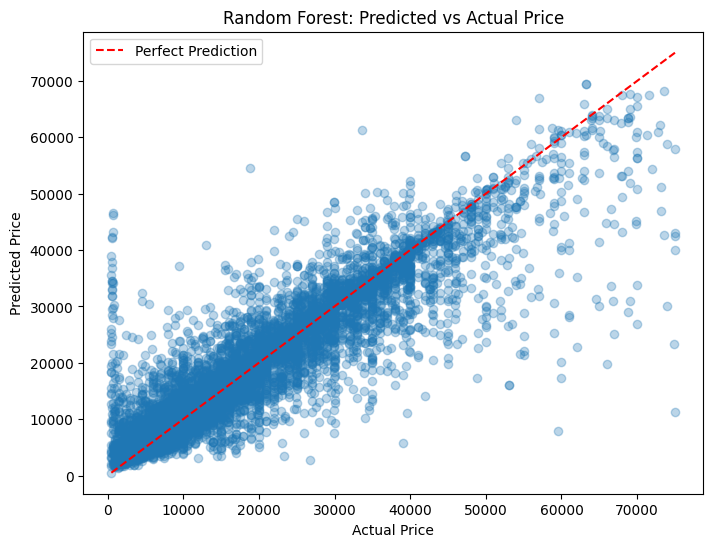

In [25]:
rf_preds = rf_pipe.predict(X_test)

# Plot predicted prices against actual listing prices to see how well our model performed
plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_preds, alpha=0.3)
plt.plot([500, 75000], [500, 75000], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest: Predicted vs Actual Price')
plt.legend()



# Model Performance - Residuals

Another way we can asses the performance of our Random Forest model is by examining a graph of the residuals.

If our model is strong, residuals should be somewhat centered around zero. If we see a lot of variation, that may highlight some weaknesses in our model.

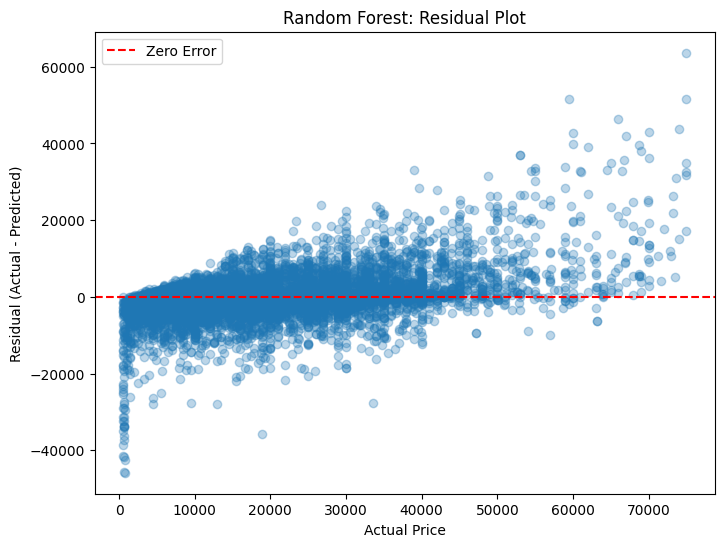

In [26]:
residuals = y_test - rf_preds

# plot residausl against actual price
plt.figure(figsize=(8,6))
plt.scatter(y_test, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Error')
plt.xlabel('Actual Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Random Forest: Residual Plot')
plt.legend()

# Conclusion

Our random forest model does a fairly good job at predicting the final sale price of a car given various inputs, predicting about 80% of variance in sale price.

Based on the residual graph and graph of predicted against actual prices, this model appears strongest for the more "average" cars for sale, between 10,000 and 40,000 to 50,000 dollars. Outside of this range, there appears to be more room for outliers, explained by usual craigslist trends that are expanded upon in the final report.

As most would expect, the most predictive features are related to vehicle age and mileage, which is consistent with what most people consider regarding the value of a used car.
